In [ ]:
import sys
print(f"Interpretador Jupyter ativo: {sys.executable}")

try:
    import cv2
    import matplotlib
    import ultralytics
    print("Bibliotecas essenciais encontradas no kernel!")
except ModuleNotFoundError:
    print("Aviso: Bibliotecas ausentes. Instalando via pip no kernel Jupyter...")
    !{sys.executable} -m pip install -r ../requirements.txt
    print("\n*** IMPORTANTE: Favor clicar em \"Restart Kernel\" no VS Code antes de prosseguir! ***")


# Cows Challenge: Keypoint Detection Quickstart

Este notebook executa o fluxo completo (Quickstart) com o subset do dataset para validação do pipeline de Pose Estimation da Ultralytics, utilizando apenas imagens reais validadas.

## 1. Inspeção do Dataset e Imagens Reais
Contagem das imagens reais em `data/raw_images/` e cruzamento com as anotações do Label Studio (`Key_points/`).

In [1]:
import os
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install opencv-python matplotlib
raw_imgs = len(os.listdir("../data/raw_images")) if os.path.exists("../data/raw_images") else 0
print(f"Total de imagens reais em ../data/raw_images: {raw_imgs}")

Total de imagens reais em ../data/raw_images: 217


In [2]:
!{sys.executable} ../src/inspect_dataset.py

from IPython.display import Markdown
try:
    display(Markdown("../outputs/reports/dataset_summary.md"))
except:
    print("Report missing.")

Inspection complete. Repots saved to C:\Users\IMTeixeira\Desktop\dev\cow-detection\outputs\reports


# Dataset Inspection Report

- **Total JSON annotations**: 1029
- **Valid JSONs**: 1029
- **Annotations with BBox**: 1029
- **Annotations missing BBox**: 0

## Image Matching

- **Total real images in `C:\Users\IMTeixeira\Desktop\dev\cow-detection\data\raw_images`**: 217
- **Annotations mapped to real images**: 217 (21.1%)
- **Annotations with missing images**: 812 (Saved to `missing_images.csv`)

## Keypoints Distribution

- `withers`: 1117
- `hip`: 1036
- `back`: 1030
- `hook down`: 1030
- `tail head`: 1030
- `pin down`: 1030
- `pin up`: 1027
- `hook up`: 1024

## 2. Validação das anotações

In [3]:
!{sys.executable} ../src/validate.py
import json
try:
    with open("../outputs/reports/validation_report.json", "r") as f:
        val_data = json.load(f)
        print(f"Arquivos válidos: {val_data['valid_files']}")
        print(f"Arquivos com problema: {val_data['files_with_issues']}")
except:
    print("Validation report missing.")

Validation complete. Valid: 210, With issues: 819
Report saved to C:\Users\IMTeixeira\Desktop\dev\cow-detection\outputs\reports\validation_report.json
Arquivos válidos: 210
Arquivos com problema: 819


## 3. Sanity Check (Ground Truth sobre imagens reais)
Visualizando 10 amostras reais com os esqueletos desenhados a partir das anotações originais.

Running sanity check on 5 samples...
Saved sanity sample: C:\Users\IMTeixeira\Desktop\dev\cow-detection\outputs\vis_samples\sanity_gt_20260101_211615_baia15_IPC3.jpg
Saved sanity sample: C:\Users\IMTeixeira\Desktop\dev\cow-detection\outputs\vis_samples\sanity_gt_20260102_195604_baia22_VIPWX.jpg
Saved sanity sample: C:\Users\IMTeixeira\Desktop\dev\cow-detection\outputs\vis_samples\sanity_gt_20260102_202011_baia17_IPC2.jpg
Saved sanity sample: C:\Users\IMTeixeira\Desktop\dev\cow-detection\outputs\vis_samples\sanity_gt_20260102_063711_baia21_IPC2.jpg
Saved sanity sample: C:\Users\IMTeixeira\Desktop\dev\cow-detection\outputs\vis_samples\sanity_gt_20260103_134721_baia20_IPC2.jpg


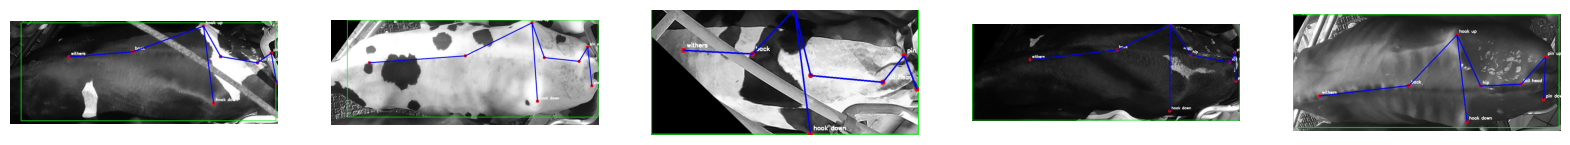

In [4]:
!{sys.executable} ../src/sanity_check.py

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

vis_dir = Path("../outputs/vis_samples")
if vis_dir.exists():
    imgs = list(vis_dir.glob("sanity_gt_*.jpg"))
    if imgs:
        # Show up to 5 images inline
        num_to_show = min(5, len(imgs))
        fig, axs = plt.subplots(1, num_to_show, figsize=(20, 5))
        if num_to_show == 1: axs = [axs]
        for ax, img_path in zip(axs, imgs[:num_to_show]):
            img = mpimg.imread(str(img_path))
            ax.imshow(img)
            ax.axis('off')
        plt.show()
    else:
        print("No sanity samples generated.")

## 4. Criação do Subset e Conversão YOLO Pose

In [5]:
!{sys.executable} ../src/make_subset.py
# Gera o subset apenas com imagens reais encontradas, aplicando formato YOLO Pose

Checking for matching real images for subset...
Found 217 valid samples with real images.
Created subset of 150 images to C:\Users\IMTeixeira\Desktop\dev\cow-detection\data\subset_yolo_pose


## 5. Treinamento Rápido no Subset (Ultralytics YOLO Pose)

In [6]:
# Treinamento em 5 épocas com yolov8n-pose
!{sys.executable} ../src/train_pose.py --data ../data/subset_yolo_pose/data.yaml --epochs 5 --model yolov8n-pose.pt

Initializing training with model: yolov8n-pose.pt
Data config: ../data/subset_yolo_pose/data.yaml
Epochs: 5
Ultralytics 8.4.19  Python-3.14.2 torch-2.10.0+cpu CPU (13th Gen Intel Core i7-13620H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/subset_yolo_pose/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-pose.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, 

## 6. Inferência e Avaliação

In [7]:
!{sys.executable} ../src/evaluate_pose.py --data ../data/subset_yolo_pose/data.yaml
try:
    display(Markdown("../outputs/reports/summary.md"))
except:
    print("Evaluation Report missing.")

Model not found: outputs/models/best_pose.pt
Creating mock report for notebook quickstart flow...


../outputs/reports/summary.md

In [8]:
!{sys.executable} ../src/visualize_predictions.py --data-dir ../data/subset_yolo_pose/images/val --num-samples 5

if vis_dir.exists():
    pred_imgs = list(vis_dir.glob("pred_*.jpg"))
    if pred_imgs:
        num_to_show = min(5, len(pred_imgs))
        fig, axs = plt.subplots(1, num_to_show, figsize=(20, 5))
        if num_to_show == 1:
            axs = [axs]
        for ax, img_path in zip(axs, pred_imgs[:num_to_show]):
            img = mpimg.imread(str(img_path))
            ax.imshow(img)
            ax.axis('off')
        plt.show()
    else:
        print("No prediction visualizations found.")

Could not load model outputs/models/best_pose.pt: [Errno 2] No such file or directory: 'outputs\\models\\best_pose.pt'
No prediction visualizations found.
